<a href="https://colab.research.google.com/github/naomiamayaa/COMP3005-Final-Project/blob/main/SYSC4415W26_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 W26 Assignment 2 – Fire Hydrant Detection 🚒

Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [7]:
# Import all the necessary libraries here

import pandas as pd
import optparse
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


Mount Google Drive and unzip the dataset.

In [8]:
## Code provided by TA. DO NOT CHANGE THIS CELL

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/FH_detection_data.zip
   creating: /content/train/
 extracting: /content/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg  
 extracting: /content/train/100_PNG.rf.d52fbff94c483761d0644a1e8abe4c95.jpg  
 extracting: /content/train/101_PNG.rf.f1335e18f815c8c8044a94c09db7f025.jpg  
 extracting: /content/train/102378468_d8132a415b_z_jpg.rf.6bc008d0d532d3365f580b7aaa7623e3.jpg  
 extracting: /content/train/102_PNG.rf.160c945e0881c92a078a14069d9a6b9a.jpg  
 extracting: /content/train/102_jpg.rf.17df75e9dda0f851c9f5e1d554f07488.jpg  
 extracting: /content/train/103357395_388d701e12_z_jpg.rf.a54c985e93402af49ba422f005e702d8.jpg  
 extracting: /content/train/103_jpg.rf.a649213f3998906bf2298607f82ee839.jpg  
 extracting: /content/train/104351403_25e959f878_z_jpg.rf.43156bd0a74313df69967d88e5e6a268.jpg  
 extrac

----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ It is important to check for class imbalance before training because a model
trained on imbalanced data may become biased toward the majority class and fail
to correctly learn the minority class.

In our dataset, the training set is relatively balanced, but the validation set
shows a strong imbalance, with significantly more images without fire hydrants
(class 0) than with hydrants (class 1). This could cause the model to achieve
high accuracy by mostly predicting the majority class, while performing poorly
at detecting fire hydrants.
..



3 pics with a fire hydrant: 


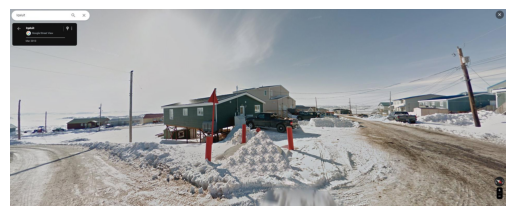

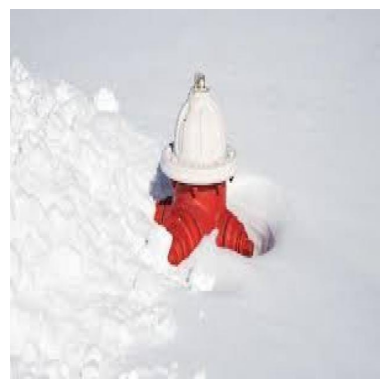

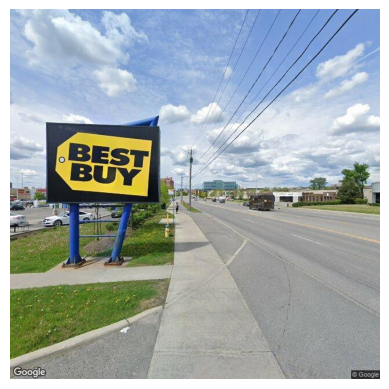


3 pics without a fire hydrant: 


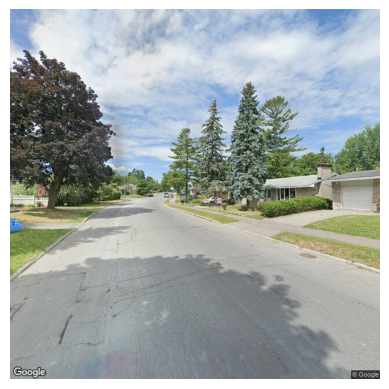

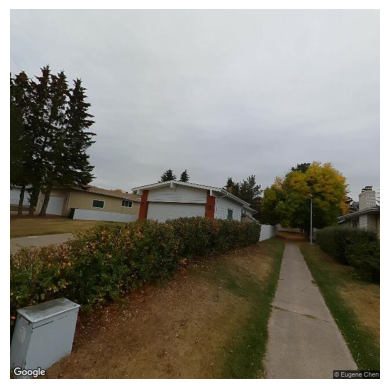

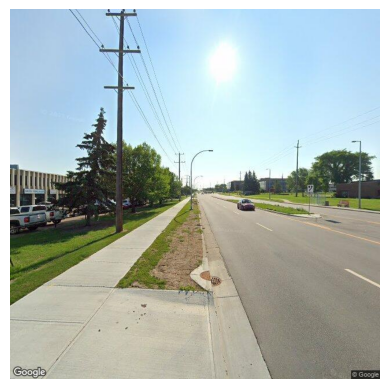

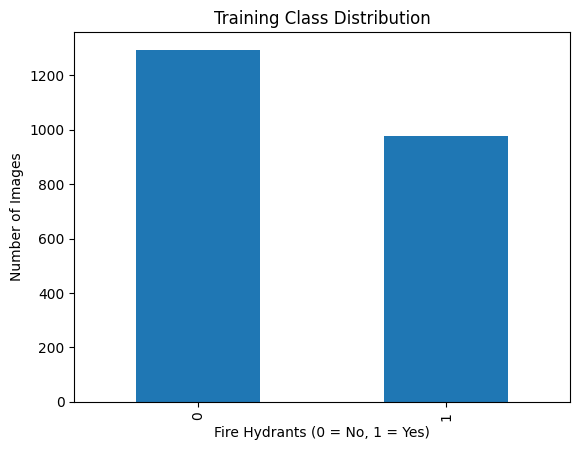

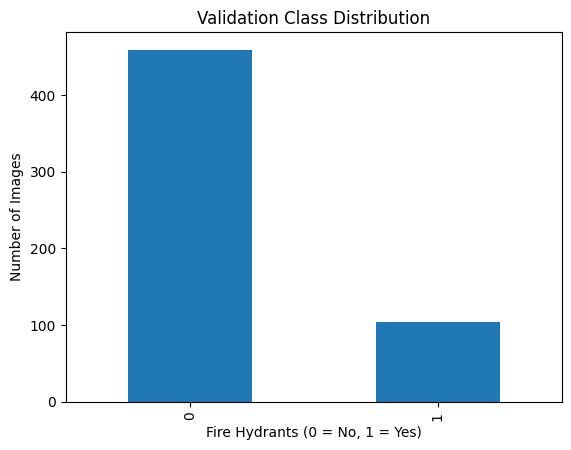

In [9]:
#1.
# Load dataset into pandas DataFrames
train_df = train_label.copy()
valid_df = valid_label.copy()

train_df.head() # check the dataset

#2.
hydrant_sample = train_df[train_df["Fire Hydrants"] == 1].head(3)
no_hydrant_sample = train_df[train_df["Fire Hydrants"] == 0].head(3)

print("\n3 pics with a fire hydrant: ")
for filename in hydrant_sample["filename"]: # pics with a fire hydrant
    path = Path(train_data_path) / filename
    img = Image.open(path)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

print("\n3 pics without a fire hydrant: ")
for filename in no_hydrant_sample["filename"]: # pics without a fire hydrant
    path = Path(train_data_path) / filename
    img = Image.open(path)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

#3.
train_counts = train_df["Fire Hydrants"].value_counts()
valid_counts = valid_df["Fire Hydrants"].value_counts()

train_counts.plot(kind="bar") # plot the training bars
plt.title("Training Class Distribution")
plt.xlabel("Fire Hydrants (0 = No, 1 = Yes)")
plt.ylabel("Number of Images")
plt.show()

valid_counts.plot(kind="bar") # plot the validation bars
plt.title("Validation Class Distribution")
plt.xlabel("Fire Hydrants (0 = No, 1 = Yes)")
plt.ylabel("Number of Images")
plt.show()


---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ One-hot encoding is not necessary for binary classification because the two
classes can be represented using a single output (0 or 1), instead of using
two-dimensional vectors like [1,0] and [0,1]. This simplifies the model and
is standard when using a sigmoid output.

In [10]:
# resize images to 128x128
# normalize pixel values for a controlled gradient
# image rotation so that model can be invariant to various orientations
# brightness change since lighting may vary a lot in pictures

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
                (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
            )
]) # transform with augmentation

valid_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
                (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
            ),
])

class FireHydrantDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df
        self.data_path = data_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(self.data_path) / row["filename"]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = row["Fire Hydrants"]
        return image, label

train_dataset = FireHydrantDataset(train_df, train_data_path, transform=train_transform)
valid_dataset = FireHydrantDataset(valid_df, valid_data_path, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)


### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅ 1. Dropout can be added to the fully connected layers to randomly deactivate
neurons during training, which helps prevent overfitting and improves generalization.

2. Batch normalization can be added after convolutional layers to normalize activations,
which helps stabilize training and leads to faster convergence.

3. Increasing the number of convolutional layers allows the model to learn more
complex features, from edges and textures to higher-level patterns, improving model performance.

In [11]:
class FireHydrantCNN(nn.Module):
    def __init__(self):
        super(FireHydrantCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(65536, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.fc_block(x)
        return x

model = FireHydrantCNN()
print(model)


FireHydrantCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_block): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ The most suitable metric is the F1-score because the dataset is imbalanced,
and the F1-score balances precision and recall. This prevents the model from
favoring the majority class (no hydrant) and provides a more reliable measure
of performance.


Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ The confusion matrix represents how well the model's predictions match the actual results.

Out of all the images, the model correctly identified 346 non-hydrant images (true negatives)
and 73 hydrant images (true positives). However, it also produced 113 false positives, where
non-hydrant images were incorrectly classified as hydrants, and 31 false negatives,
where actual hydrants were missed.

This indicates that the model is strong at recognizing the majority class (no hydrant)
but tends to over-predict the presence of hydrants.

cuda
cpu
[INFO] Training network...


Epoch 1/10: 100%|██████████| 71/71 [00:19<00:00,  3.57it/s, loss=0.6279]



Epoch 1: Train Loss = 0.6279, Val Loss = 0.4782


Epoch 2/10: 100%|██████████| 71/71 [00:17<00:00,  4.03it/s, loss=0.5612]



Epoch 2: Train Loss = 0.5612, Val Loss = 0.5213


...


Epoch 8: Train Loss = 0.4550, Val Loss = 0.4881


Epoch 9/10: 100%|██████████| 71/71 [00:17<00:00,  4.06it/s, loss=0.4541]



Epoch 9: Train Loss = 0.4541, Val Loss = 0.4634


Epoch 10/10: 100%|██████████| 71/71 [00:18<00:00,  3.78it/s, loss=0.4386]



Epoch 10: Train Loss = 0.4386, Val Loss = 0.4633
[INFO] Evaluating model...

Evaluation Metrics:
Precision: 0.4552
Recall:    0.5865
F1-score:  0.5126

Confusion Matrix:

Confusion Matrix:
[[386  73]
 [ 43  61]]


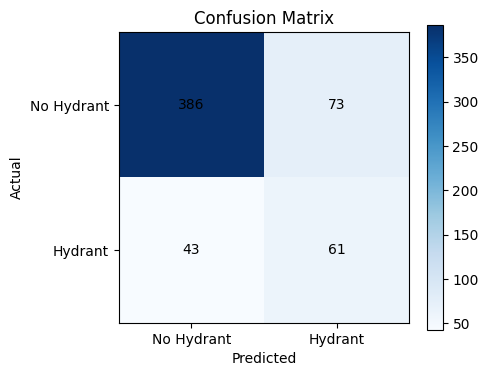

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print(next(model.parameters()).device)

model = FireHydrantCNN().to(device)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_cnn(epochs, model, criterion, optimizer, train_loader, valid_loader):
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        # train
        model.train()
        running_loss = 0.0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for i, (images, labels) in enumerate(train_pbar):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            train_pbar.set_postfix({
                "loss": f"{running_loss/(i+1):.4f}"
            })

        train_loss = running_loss / len(train_loader)

        # val
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(valid_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"\nEpoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    return model, history

def evaluate_model(model, valid_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)

            outputs = model(images)
            preds = (outputs > 0.5).float().cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print("\nEvaluation Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()

    classes = ["No Hydrant", "Hydrant"]
    plt.xticks(np.arange(len(classes)), classes)
    plt.yticks(np.arange(len(classes)), classes)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()

    return precision, recall, f1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FireHydrantCNN().to(device)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10

print("[INFO] Training network...")
model, history = train_cnn(EPOCHS, model, criterion, optimizer, train_loader, valid_loader)

print("[INFO] Evaluating model...")
precision, recall, f1 = evaluate_model(model, valid_loader)


def run_experiment(model_class, model_name):
    print(f"\n[INFO] Running experiment: {model_name}")

    # initialize model
    model = model_class().to(device)

    # loss + optimizer (since you added Sigmoid → use BCELoss)
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # train
    model, history = train_cnn(
        EPOCHS,
        model,
        criterion,
        optimizer,
        train_loader,
        valid_loader
    )

    # evaluate
    precision, recall, f1 = evaluate_model(model, valid_loader)

    return model, precision, recall, f1


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ I would deploy the original model because it achieved the highest F1-score, indicating the best balance between precision and recall. The modified models did not outperform it, likely due to increased complexity and instability on a relatively small and imbalanced dataset.

cuda
cuda:0

[INFO] Running experiment: Dropout


Epoch 1/10: 100%|██████████| 71/71 [00:18<00:00,  3.76it/s, loss=0.6625]



Epoch 1: Train Loss = 0.6625, Val Loss = 0.5259


Epoch 2/10: 100%|██████████| 71/71 [00:17<00:00,  4.15it/s, loss=0.5695]



Epoch 2: Train Loss = 0.5695, Val Loss = 0.4916


...


Epoch 8: Train Loss = 0.4517, Val Loss = 0.4613


Epoch 9/10: 100%|██████████| 71/71 [00:18<00:00,  3.89it/s, loss=0.4386]



Epoch 9: Train Loss = 0.4386, Val Loss = 0.5085


Epoch 10/10: 100%|██████████| 71/71 [00:18<00:00,  3.83it/s, loss=0.4410]



Epoch 10: Train Loss = 0.4410, Val Loss = 0.5657

Evaluation Metrics:
Precision: 0.3348
Recall:    0.7500
F1-score:  0.4629

Confusion Matrix:

Confusion Matrix:
[[304 155]
 [ 26  78]]


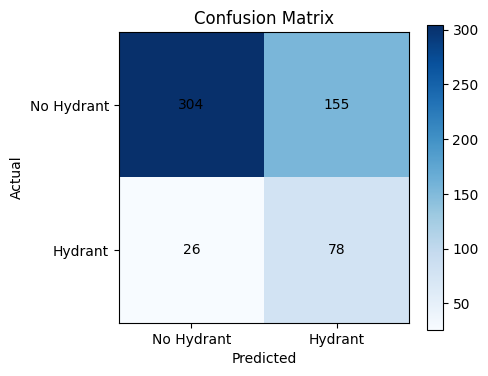


[INFO] Running experiment: BatchNorm


Epoch 1/10: 100%|██████████| 71/71 [00:18<00:00,  3.86it/s, loss=7.7705]



Epoch 1: Train Loss = 7.7705, Val Loss = 0.5820


Epoch 2/10: 100%|██████████| 71/71 [00:17<00:00,  4.04it/s, loss=0.5623]



Epoch 2: Train Loss = 0.5623, Val Loss = 0.4341


...


Epoch 8: Train Loss = 0.4095, Val Loss = 0.4438


Epoch 9/10: 100%|██████████| 71/71 [00:17<00:00,  4.03it/s, loss=0.3963]



Epoch 9: Train Loss = 0.3963, Val Loss = 0.5721


Epoch 10/10: 100%|██████████| 71/71 [00:18<00:00,  3.88it/s, loss=0.3773]



Epoch 10: Train Loss = 0.3773, Val Loss = 0.5879

Evaluation Metrics:
Precision: 0.3989
Recall:    0.6827
F1-score:  0.5035

Confusion Matrix:

Confusion Matrix:
[[352 107]
 [ 33  71]]


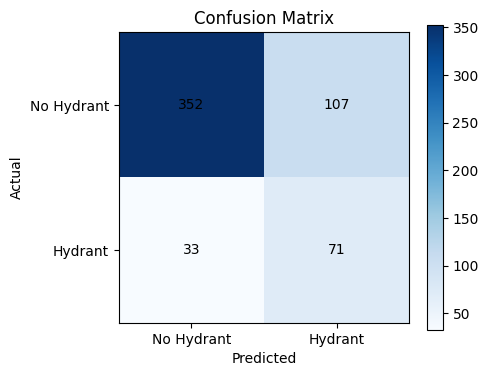


[INFO] Running experiment: MoreConv


Epoch 1/10: 100%|██████████| 71/71 [00:18<00:00,  3.76it/s, loss=0.6218]



Epoch 1: Train Loss = 0.6218, Val Loss = 0.5004


Epoch 2/10: 100%|██████████| 71/71 [00:17<00:00,  4.03it/s, loss=0.5575]



Epoch 2: Train Loss = 0.5575, Val Loss = 0.4392


...


Epoch 8: Train Loss = 0.4409, Val Loss = 0.5678


Epoch 9/10: 100%|██████████| 71/71 [00:21<00:00,  3.36it/s, loss=0.4369]



Epoch 9: Train Loss = 0.4369, Val Loss = 0.5289


Epoch 10/10: 100%|██████████| 71/71 [00:18<00:00,  3.94it/s, loss=0.4210]



Epoch 10: Train Loss = 0.4210, Val Loss = 0.4633

Evaluation Metrics:
Precision: 0.4200
Recall:    0.6058
F1-score:  0.4961

Confusion Matrix:

Confusion Matrix:
[[372  87]
 [ 41  63]]


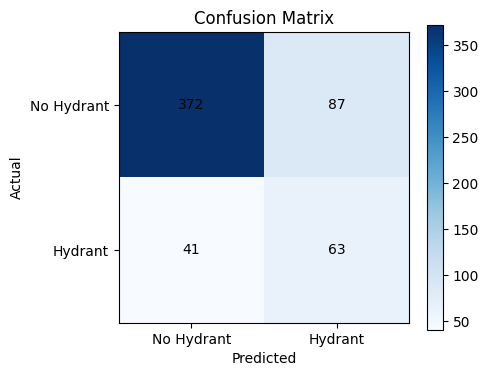


Final Model Comparison:
           Precision    Recall  F1-Score
Dropout     0.334764  0.750000  0.462908
BatchNorm   0.398876  0.682692  0.503546
MoreConv    0.420000  0.605769  0.496063


In [15]:
print(device)
print(next(model.parameters()).device)

class FireHydrantCNN_Dropout(nn.Module):
    def __init__(self):
        super(FireHydrantCNN_Dropout, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),  # add dropout
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.fc_block(x)
        return x

class FireHydrantCNN_BatchNorm(nn.Module):
    def __init__(self):
        super(FireHydrantCNN_BatchNorm, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),  # batch norm
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),  # batch norm
            nn.MaxPool2d(2)
        )

        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.fc_block(x)
        return x

class FireHydrantCNN_MoreConv(nn.Module):
    def __init__(self):
        super(FireHydrantCNN_MoreConv, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block3 = nn.Sequential(   # new convolution lauer
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),  # updated model size
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.fc_block(x)
        return x

results = {}

# Dropout model
model_dropout, precision, recall, f1 = run_experiment(FireHydrantCNN_Dropout, "Dropout")
results["Dropout"] = (precision, recall, f1)

# BatchNorm model
model_batchnorm, precision, recall, f1 = run_experiment(FireHydrantCNN_BatchNorm, "BatchNorm")
results["BatchNorm"] = (precision, recall, f1)

# MoreConv model
model_moreconv, precision, recall, f1 = run_experiment(FireHydrantCNN_MoreConv, "MoreConv")
results["MoreConv"] = (precision, recall, f1)

results_df = pd.DataFrame(
    results,
    index=["Precision", "Recall", "F1-Score"]
).T

print("\nFinal Model Comparison:")
print(results_df)


---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ Yes, the model incorrectly predicted a fire hydrant in an image that contained objects with prominent shapes, such as tree or big snowbank. This suggests that the model is relying heavily on simple visual cues like color and shape rather than understanding the full context of the scene.

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅ The model performed well on images where the fire hydrant was clearly visible, centered, and close to the camera. In these cases, the hydrant’s distinct yellow color and shape made it easier for the model to correctly identify it.
However, the model struggled in images where the hydrant was far away or small in the frame. For example, in one image the hydrant was present but very small and partially obscured, which led to a missed detection.
A clear pattern is that the model relies heavily on size and visibility, performing best when the hydrant is large and prominent. It also tends to rely on color cues (yellow), which can lead to false positives in scenes without hydrants but with similar colors or vertical shapes.
Additionally, snowy and cluttered backgrounds sometimes confuse the model, suggesting it has difficulty distinguishing hydrants from the surrounding environment when contrast is low.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

0BFDB45B-E6D5-4D90-8D3B-19EB5509A206_1_105_c.jpeg: Hydrant


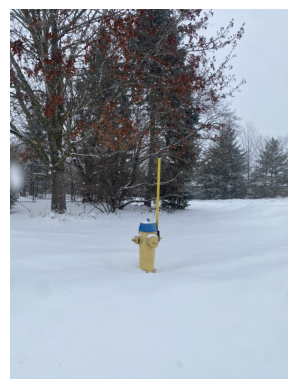


0A7EE74D-2633-440F-B30E-5C3C918F8BA2_1_105_c.jpeg: No Hydrant


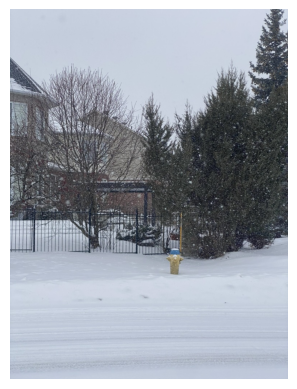


92A53611-DB0C-46B7-B7AD-C245C6EEA306_1_105_c.jpeg: Hydrant


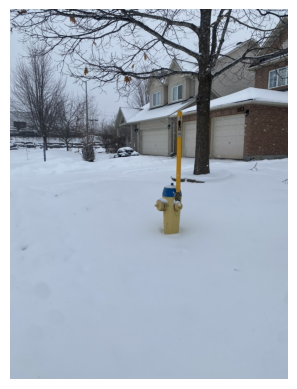


2E7CB739-8262-446C-B75E-D1B057032895_1_105_c.jpeg: Hydrant


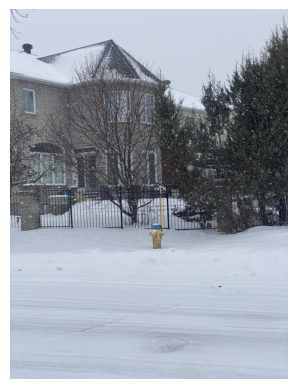


0025C012-ABC1-4A07-BA3B-F253B1F65569_1_105_c.jpeg: Hydrant


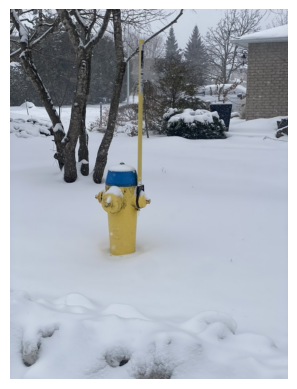


1FEA3F99-0C89-4A28-AAC1-C72C406E4DFE_1_105_c.jpeg: Hydrant


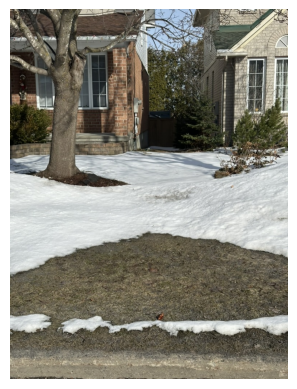


04042BD7-A0B4-4154-B791-50BEA30758DD_1_105_c.jpeg: Hydrant


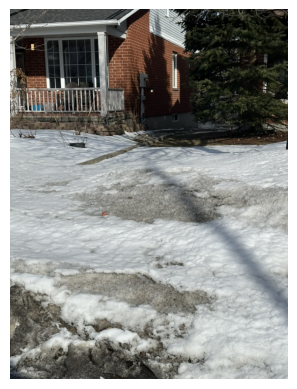


F99A565E-2602-48DE-8E29-EDB133E347E4_1_105_c.jpeg: Hydrant


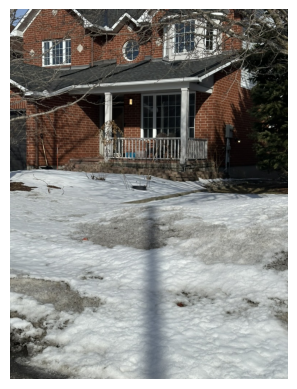


E59DBE35-17E9-4621-B057-912F1E454FA5_1_105_c.jpeg: Hydrant


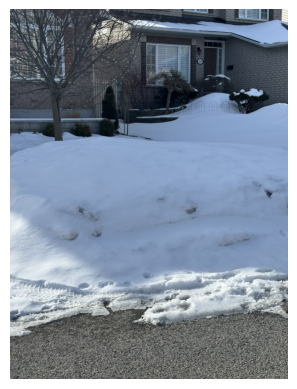


83F0825D-FC84-40C3-B7CF-26D11F500597_1_105_c.jpeg: Hydrant


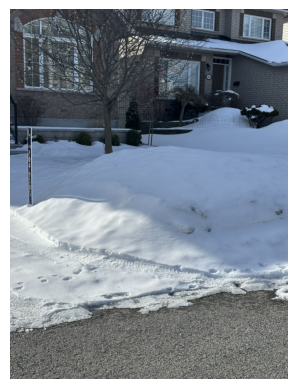


4CF50AF2-8C16-44A0-9476-3A980A5EA49E_1_105_c.jpeg: Hydrant


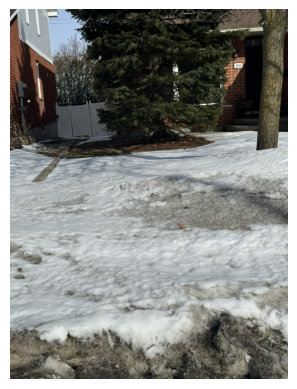


Screenshot 2026-03-26 at 8.12.10 PM.png: No Hydrant


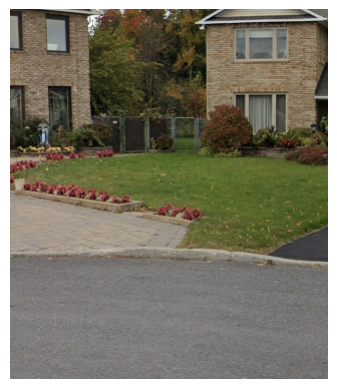


Screenshot 2026-03-26 at 8.12.48 PM.png: Hydrant


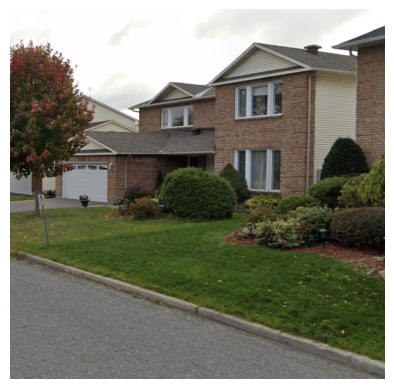

In [17]:

from google.colab import drive
drive.mount('/content/drive')

test = "/content/drive/MyDrive/a2_test_folder/"

model.eval()

for img in os.listdir(test):
    img_path = os.path.join(test, img)

    # preprocess
    image = Image.open(img_path)
    img_tensor = valid_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        pred = (outputs > 0.5).item()

    print(f"\n{img}: {'Hydrant' if pred == 1 else 'No Hydrant'}")

    plt.imshow(image)
    plt.axis("off")
    plt.show()


---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ I would improve the model by increasing the dataset size and including images from different seasons to improve generalization. I would also address class imbalance by adding more non-hydrant images, especially ones that look similar to hydrants, to reduce false positives. Additionally, I would experiment with adjusting the decision threshold and using transfer learning rather than building from scratch to help the model learn stronger and more robust features.


-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ I used ChatGPT to improve the structure of my sentences and detect any grammar mistakes made. I also used it for debugging errors and to better interpret code. For example, I asked questions about why my BatchNorm model was performing poorly and how to fix issues in my training loop and inference code.

To validate the responses, I tested all suggested changes in my code and ensured that the results made sense (e.g., improved metrics or correct outputs). I also compared the suggestions with lecture materials and class examples to confirm their correctness.

---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

